In [8]:
#mengimport library Pandas
import pandas as pd
pd.set_option('display.max_column', 10)

#membaca dataset credit_scoring_dqlab dari file excel
dataset_credit_scoring = pd.read_excel('credit_scoring.xlsx')
print('Dataset credit scoring:')
print(dataset_credit_scoring)

print('\nInformasi dataset:')
dataset_credit_scoring.info()

Dataset credit scoring:
    kode_kontrak  pendapatan_setahun_juta kpr_aktif  durasi_pinjaman_bulan  \
0     AGR-000001                      295        YA                     48   
1     AGR-000011                      271        YA                     36   
2     AGR-000030                      159     TIDAK                     12   
3     AGR-000043                      210        YA                     12   
4     AGR-000049                      165     TIDAK                     36   
..           ...                      ...       ...                    ...   
895   AGR-010739                      112        YA                     48   
896   AGR-010744                      120        YA                     48   
897   AGR-010758                      166     TIDAK                     24   
898   AGR-010775                      196     TIDAK                     48   
899   AGR-010790                      204     TIDAK                     24   

     jumlah_tanggungan rata_rata_overdu

In [9]:
##Mengubah Kolom kpr_aktif menjadi Numerik
import pandas as pd
pd.set_option('display.max_column', 10)

dataset_credit_scoring = pd.read_excel('credit_scoring.xlsx')

#mengubah data kpr_aktif menjadi tipe integer
dataset_credit_scoring['kpr_aktif'].replace(['YA', 'TIDAK'],[1, 0], inplace=True)

print('Dataset credit scoring:')
print(dataset_credit_scoring)

Dataset credit scoring:
    kode_kontrak  pendapatan_setahun_juta  kpr_aktif  durasi_pinjaman_bulan  \
0     AGR-000001                      295          1                     48   
1     AGR-000011                      271          1                     36   
2     AGR-000030                      159          0                     12   
3     AGR-000043                      210          1                     12   
4     AGR-000049                      165          0                     36   
..           ...                      ...        ...                    ...   
895   AGR-010739                      112          1                     48   
896   AGR-010744                      120          1                     48   
897   AGR-010758                      166          0                     24   
898   AGR-010775                      196          0                     48   
899   AGR-010790                      204          0                     24   

     jumlah_tanggungan rata

In [10]:
##Mengubah Kolom rata_rata_overdue Menjadi Numerik
#Kode sebelumnya
import pandas as pd
pd.set_option('display.max_column', 10)

dataset_credit_scoring = pd.read_excel('credit_scoring.xlsx')

dataset_credit_scoring['kpr_aktif'].replace(['YA', 'TIDAK'],[1, 0], inplace=True)

# Label Encoding rata_rata_overdue, untuk menghilangkan value string, sehingga bisa dibuat dalam bentuk numeric array, dan tidak error saat membuat modelnya
dataset_credit_scoring['rata_rata_overdue'].replace({'0 - 30 days':1, '31 - 45 days':2, '46 - 60 days':3, '61 - 90 days':4, '> 90 days':5}, inplace=True)

print('Dataset credit scoring:')
print(dataset_credit_scoring)

Dataset credit scoring:
    kode_kontrak  pendapatan_setahun_juta  kpr_aktif  durasi_pinjaman_bulan  \
0     AGR-000001                      295          1                     48   
1     AGR-000011                      271          1                     36   
2     AGR-000030                      159          0                     12   
3     AGR-000043                      210          1                     12   
4     AGR-000049                      165          0                     36   
..           ...                      ...        ...                    ...   
895   AGR-010739                      112          1                     48   
896   AGR-010744                      120          1                     48   
897   AGR-010758                      166          0                     24   
898   AGR-010775                      196          0                     48   
899   AGR-010790                      204          0                     24   

     jumlah_tanggungan  rat

In [11]:
##Feature Matrix X (Independent Variables)
#Kode sebelumnya
import pandas as pd

dataset_credit_scoring = pd.read_excel('credit_scoring.xlsx')

dataset_credit_scoring['kpr_aktif'].replace(['YA', 'TIDAK'], [1, 0], inplace=True)

dataset_credit_scoring['rata_rata_overdue'].replace({'0 - 30 days':1, '31 - 45 days':2, '46 - 60 days':3, '61 - 90 days':4, '> 90 days':5}, inplace=True)

#untuk X (independent variables), data yang dimasukkan semua persyaratan untuk membuat risk_rating (variabel dependen), tidak memerlukan kode_kontrak, sehingga kolom kode_kontrak,  risk_rating, dan rata_rata_overdue dibuang
X=dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue']).values
print('Ukuran matrix feature X:', X.shape)

Ukuran matrix feature X: (900, 4)


In [12]:
##Target y (Dependent Variable)
#Kode sebelumnya
import pandas as pd

dataset_credit_scoring = pd.read_excel('credit_scoring.xlsx')

dataset_credit_scoring['kpr_aktif'].replace(['YA', 'TIDAK'], [1, 0], inplace=True)

dataset_credit_scoring['rata_rata_overdue'].replace({'0 - 30 days':1, '31 - 45 days':2, '46 - 60 days':3, '61 - 90 days':4, '> 90 days':5}, inplace=True)

X = dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue']).values

#kolom Y (target/dependent variable) adalah target nilai yang harus dibuat sistem ketika membaca data X isinya adalah kolom risk_rating
y = dataset_credit_scoring['risk_rating'].values
print('Ukuran target y:', y.shape)

Ukuran target y: (900,)


In [13]:
##Data Training dan Data Testing
#Kode sebelumnya
import pandas as pd

dataset_credit_scoring = pd.read_excel('credit_scoring.xlsx')

dataset_credit_scoring['kpr_aktif'].replace(['YA', 'TIDAK'], [1, 0], inplace=True)

dataset_credit_scoring['rata_rata_overdue'].replace({'0 - 30 days':1, '31 - 45 days':2, '46 - 60 days':3, '61 - 90 days':4, '> 90 days':5}, inplace=True)

X = dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue']).values
y = dataset_credit_scoring['risk_rating'].values

#membagi data training dan data testing, dimana training 70% dan testing 30%
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
 
#menampilkan jumlah data train dan test
print('Ukuran X_train:', X_train.shape)
print('Ukuran X_test :', X_test.shape)
print('Ukuran y_train:', y_train.shape)
print('Ukuran y_test :', y_test.shape)

Ukuran X_train: (630, 4)
Ukuran X_test : (270, 4)
Ukuran y_train: (630,)
Ukuran y_test : (270,)


In [21]:
##Membangun Random Forest Classifier
#Kode sebelumnya
import pandas as pd

dataset_credit_scoring = pd.read_excel('credit_scoring.xlsx')

dataset_credit_scoring['kpr_aktif'].replace(['YA', 'TIDAK'], [1, 0], inplace=True)

dataset_credit_scoring['rata_rata_overdue'].replace({'0 - 30 days':1, '31 - 45 days':2, '46 - 60 days':3, '61 - 90 days':4, '> 90 days':5}, inplace=True)

X = dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue']).values
y = dataset_credit_scoring['risk_rating'].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

#membangun Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Nilai Entropy menentukan bagaimana sebuah Decision Tree melakukan pemisahan data. Nilai Entropi berpengaruh ketika decision tree menentukan batasan/boundaries - nya. random_state digunakan untuk menentukan jumlah bootstrapping sample yang akan dilakukan. Nilai random state yang banyak digunakan adalah 0 dan 42.
rfc = RandomForestClassifier(criterion='entropy', random_state=42)
model = rfc.fit(X_train, y_train)
print(model)

RandomForestClassifier(criterion='entropy', random_state=42)


In [14]:
##Feature Importance
#Kode sebelumnya
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

dataset_credit_scoring = pd.read_excel('credit_scoring.xlsx')

dataset_credit_scoring['kpr_aktif'].replace(['YA', 'TIDAK'], [1, 0], inplace=True)

dataset_credit_scoring['rata_rata_overdue'].replace({'0 - 30 days':1, '31 - 45 days':2, '46 - 60 days':3, '61 - 90 days':4, '> 90 days':5}, inplace=True)

X = dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue']).values
y = dataset_credit_scoring['risk_rating'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

rfc = RandomForestClassifier(criterion='entropy', random_state=42)
model = rfc.fit(X_train, y_train)

#mendapatkan importance
importance = model.feature_importances_

#nama feature
feature_names = dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue']).columns

#summarize feature importance
for f, fi in zip(feature_names, importance):
	print('Feature: %24s, Score: %.5f' % (f, fi))

Feature:  pendapatan_setahun_juta, Score: 0.22462
Feature:                kpr_aktif, Score: 0.37739
Feature:    durasi_pinjaman_bulan, Score: 0.09436
Feature:        jumlah_tanggungan, Score: 0.30364


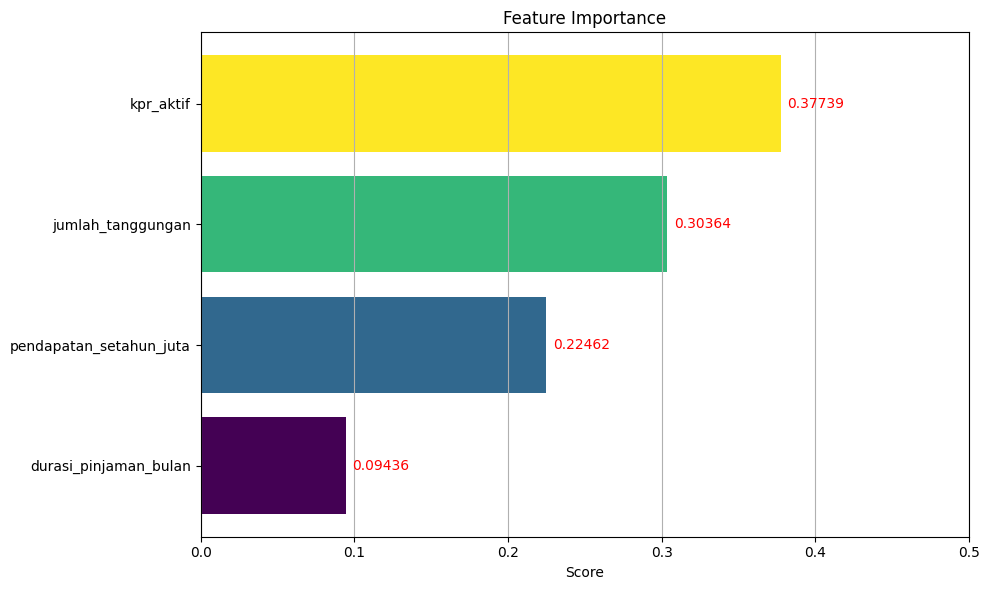

In [20]:
##Visualisasi Feature Importance dengan Bar Chart
#Kode sebelumnya
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

dataset_credit_scoring = pd.read_excel('credit_scoring.xlsx')

dataset_credit_scoring['kpr_aktif'].replace(['YA', 'TIDAK'], [1, 0], inplace=True)

dataset_credit_scoring['rata_rata_overdue'].replace({'0 - 30 days':1, '31 - 45 days':2, '46 - 60 days':3, '61 - 90 days':4, '> 90 days':5}, inplace=True)

X = dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue']).values
y = dataset_credit_scoring['risk_rating'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

rfc = RandomForestClassifier(criterion='entropy', random_state=42)
model = rfc.fit(X_train, y_train)

importance = model.feature_importances_
feature_names = dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue']).columns

#Buat data frame agar lebih mudah dalam pengurutan
fi_df = pd.DataFrame({'Feature': feature_names, 'Score': importance}).sort_values('Score')

#import matplotlib dan plot fi_df
import matplotlib.pyplot as plt

# Tambahin list warna otomatis berdasarkan jumlah bar
colors = plt.cm.viridis(np.linspace(0, 1, len(fi_df)))

plt.figure(figsize=(10, 6)) # Biar ukurannya lebih enak dilihat
barh = plt.barh(fi_df['Feature'], fi_df['Score'], color=colors) # Tambah parameter color di sini
plt.bar_label(barh, fmt='%.5f', padding=5, c='red')
plt.title('Feature Importance')
plt.xlabel('Score')
plt.xlim([0, 0.5])
plt.grid(axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png') # Otomatis simpan buat kebutuhan GitHub kamu
plt.show()

In [15]:
##Menghilangkan Kolom durasi_pinjaman_bulan
#Kode sebelumnya
import pandas as pd
from sklearn.model_selection import train_test_split

dataset_credit_scoring = pd.read_excel('credit_scoring.xlsx')

dataset_credit_scoring['kpr_aktif'].replace(['YA', 'TIDAK'], [1, 0], inplace=True)

dataset_credit_scoring['rata_rata_overdue'].replace({'0 - 30 days':1, '31 - 45 days':2, '46 - 60 days':3, '61 - 90 days':4, '> 90 days':5}, inplace=True)

X = dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue']).values
y = dataset_credit_scoring['risk_rating'].values

#Feature matrix X1
X1 = dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue', 'durasi_pinjaman_bulan']).values

#membagi data training dan data testing, dimana training 70% dan testing 30%
X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.3, random_state=0)
 
#menampilkan jumlah data train dan test
print('Ukuran X_train:', X_train.shape)
print('Ukuran X_test :', X_test.shape)
print('Ukuran y_train:', y_train.shape)
print('Ukuran y_test :', y_test.shape)

Ukuran X_train: (630, 3)
Ukuran X_test : (270, 3)
Ukuran y_train: (630,)
Ukuran y_test : (270,)


In [25]:
##Melakukan pemodelan ulang
#Kode sebelumnya
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

dataset_credit_scoring = pd.read_excel('credit_scoring.xlsx')

dataset_credit_scoring['kpr_aktif'].replace(['YA', 'TIDAK'], [1, 0], inplace=True)

dataset_credit_scoring['rata_rata_overdue'].replace({'0 - 30 days':1, '31 - 45 days':2, '46 - 60 days':3, '61 - 90 days':4, '> 90 days':5}, inplace=True)

X = dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue']).values
y = dataset_credit_scoring['risk_rating'].values

X1 = dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue', 'durasi_pinjaman_bulan']).values

X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.3, random_state=0)

#Melakukan pemodelan ulang dengan Random Forest
rfc = RandomForestClassifier(criterion='entropy', random_state=42)
model = rfc.fit(X_train, y_train)

# Melihat hyperparameters yang tersedia
from pprint import pprint

print('Hyperparameters yang sedang digunakan:')
pprint(rfc.get_params())

Hyperparameters yang sedang digunakan:
{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}


In [16]:
##Hyperparameter untuk RandomizedGridCV
import numpy as np
from pprint import pprint

#jumlah pohon pada random forest
n_estimators = list(np.linspace(200, 2000, num=100, dtype=np.int32))
 
#jumlah fitur yang dipertimbangkan untuk setiap pemisahan (split)
max_features = ['auto', 'sqrt']
 
#jumlah maksimum level pada setiap pohon
max_depth = list(np.linspace(10, 110, num=11, dtype=np.int32))
max_depth.append(None)
 
#jumlah minimum sample yang dibutuhkan untuk memisahkan node
min_samples_split = [2, 5, 10]
 
#jumlah minimum sample yang dibutuhkan untuk setiap leaf node
min_samples_leaf = [1, 2, 4]
 
#metode untuk memilih sampel untuk training setiap pohon
bootstrap = [True, False]
 
#membuat random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

pprint(random_grid)

{'bootstrap': [True, False],
 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, None],
 'max_features': ['auto', 'sqrt'],
 'min_samples_leaf': [1, 2, 4],
 'min_samples_split': [2, 5, 10],
 'n_estimators': [200,
                  218,
                  236,
                  254,
                  272,
                  290,
                  309,
                  327,
                  345,
                  363,
                  381,
                  400,
                  418,
                  436,
                  454,
                  472,
                  490,
                  509,
                  527,
                  545,
                  563,
                  581,
                  600,
                  618,
                  636,
                  654,
                  672,
                  690,
                  709,
                  727,
                  745,
                  763,
                  781,
                  800,
                  81

In [27]:
##Random forest dengan RandomizedGridCV
#Kode sebelumnya
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from pprint import pprint

dataset_credit_scoring = pd.read_excel('credit_scoring.xlsx')

dataset_credit_scoring['kpr_aktif'].replace(['YA', 'TIDAK'], [1, 0], inplace=True)

dataset_credit_scoring['rata_rata_overdue'].replace({'0 - 30 days':1, '31 - 45 days':2, '46 - 60 days':3, '61 - 90 days':4, '> 90 days':5}, inplace=True)

X = dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue']).values
y = dataset_credit_scoring['risk_rating'].values

X1 = dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue', 'durasi_pinjaman_bulan']).values

X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.3, random_state=0)

n_estimators = list(np.linspace(200, 2000, num=100, dtype=np.int32))

max_features = ['auto', 'sqrt']
 
max_depth = list(np.linspace(10, 110, num=11, dtype=np.int32))
max_depth.append(None)
 
min_samples_split = [2, 5, 10]
 
min_samples_leaf = [1, 2, 4]
 
bootstrap = [True, False]
 
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

#Random Forest
rfc = RandomForestClassifier(criterion='entropy', random_state=42)

#Import RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

#Menggunakan random grid untuk mencari hyperparameters terbaik 
rf_random = RandomizedSearchCV(estimator=rfc, param_distributions=random_grid, n_iter=10, cv=3, verbose=2, random_state=0)

#Fit the random search model
rf_random.fit(X_train, y_train)

#Tampilkan parameter terbaik
print('\nParameter terbaik:')
pprint(rf_random.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=781; total time=  17.1s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=781; total time=   6.2s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=781; total time=   5.7s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=436; total time=   2.4s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=436; total time=   2.2s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=436; total time=   2.3s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators

c:\Users\Annisya Salsabila H\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
6 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Annisya Salsabila H\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Annisya Salsabila H\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
  File "c:\Users\Annisya Salsabila H\AppData\Local\Progr


Parameter terbaik:
{'bootstrap': False,
 'max_depth': 100,
 'max_features': 'sqrt',
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'n_estimators': 418}


In [17]:
##Base Model vs Best Model
#Kode sebelumnya
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

dataset_credit_scoring = pd.read_excel('credit_scoring.xlsx')

dataset_credit_scoring['kpr_aktif'].replace(['YA', 'TIDAK'], [1, 0], inplace=True)

dataset_credit_scoring['rata_rata_overdue'].replace({'0 - 30 days':1, '31 - 45 days':2, '46 - 60 days':3, '61 - 90 days':4, '> 90 days':5}, inplace=True)

X = dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue']).values
y = dataset_credit_scoring['risk_rating'].values

X1 = dataset_credit_scoring.drop(columns=['kode_kontrak', 'risk_rating', 'rata_rata_overdue', 'durasi_pinjaman_bulan']).values

X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.3, random_state=0)

n_estimators = list(np.linspace(200, 2000, num=100, dtype=np.int32))

max_features = ['auto', 'sqrt']
 
max_depth = list(np.linspace(10, 110, num=11, dtype=np.int32))
max_depth.append(None)
 
min_samples_split = [2, 5, 10]
 
min_samples_leaf = [1, 2, 4]
 
bootstrap = [True, False]
 
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

rfc = RandomForestClassifier(criterion='entropy', random_state=42)

rf_random = RandomizedSearchCV(estimator=rfc, param_distributions=random_grid, n_iter=10, cv=3, verbose=0, random_state=0)
rf_random.fit(X_train, y_train)

#Fungsi untuk mengevaluasi model berdasarkan data testing
def evaluate(model, X_test, y_test):
    predictions = model.predict(X_test)
    errors = abs(predictions - y_test)
    mape = 100 * np.mean(errors / y_test)
    accuracy = 100 - mape
    print('Model Performance')
    print('Average Error: %.4f degrees.' % (np.mean(errors),))
    print('Accuracy = %.2f%%.' % (accuracy,))
    
#Base Model
base_model = rfc.fit(X_train, y_train)
print('Base Model:')
print('-----------')
evaluate(base_model, X_test, y_test)

#Best Model
best_model = rf_random.best_estimator_
print('\n\nBest Model:')
print('-----------')
evaluate(best_model, X_test, y_test)

c:\Users\Annisya Salsabila H\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
6 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Annisya Salsabila H\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Annisya Salsabila H\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
  File "c:\Users\Annisya Salsabila H\AppData\Local\Progr

Base Model:
-----------
Model Performance
Average Error: 0.2556 degrees.
Accuracy = 86.65%.


Best Model:
-----------
Model Performance
Average Error: 0.2148 degrees.
Accuracy = 88.23%.
